In [68]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [69]:
df = pd.read_csv("../Data/cleaned_dataset.csv")

df.head()

,house_number,name,phone_number,area,family_size,diet_type,meat_days,vegetables,fruits,food_grains,rice_type,dairy_products,rice_per_day,rice_per_month,milk_per_week,grocery_source,vegetable_frequency,grocery_frequency
0,201,p mahema sai,9739697840,doddakallasandra,4.0,Non_Vegetarian,wednesday;friday;sunday,onion;tomato;carrot;potato;beans;chilli,banana;apple;orange;grapes;watermelon;pomegranate,rice;millets;ragi;wheat,white rice;basmati;brown rice,milk;curd;panner;buttermilk;ice cream,0.5,6.0,5.0,Metro,weekly once,Monthly
1,20,namitha n reddy,9108291205,koramangala,5.0,Vegetarian,not_applicable,onion;tomato;carrot;potato;beans;cabbage;drums...,banana;apple;orange;papaya;guava;kiwi,rice;millets;ragi;barley,white rice,milk;curd;panner,0.5,6.0,5.0,local kirana stores,Biweekly,Biweekly
2,703,n,9876512349,doddakallasandra,4.0,Vegetarian,not_applicable,tomato;carrot;potato;beans;chilli,banana;apple;orange;papaya;guava,rice;jawar;millets;wheat,white rice;sona masuri;idli/dosa rice;brown rice,milk;curd;panner;buttermilk;ice cream,0.5,6.0,3.0,Blinkit,weekly twice,weekly once
3,251,shobhika santhosh,7022167063,hsr layout,3.0,Non_Vegetarian,wednesday;friday;saturday;sunday,onion;tomato;carrot;potato;brinjal;beans;cabba...,banana;apple;mango,rice;millets;ragi;wheat,red rice/rajamudi,milk;curd;panner;buttermilk;ice cream,0.5,3.0,1.0,lulu daily,weekly once,Biweekly
4,147,NaN,9513144130,vijayanagar,4.0,Eggetarian,not_applicable,onion;tomato;carrot;beans;cabbage,banana;apple;orange;papaya,rice;millets;wheat;maize,white rice;sona masuri;idli/dosa rice,milk;curd,0.5,6.0,7.0,amazon fresh & amazon now,weekly twice,Biweekly


In [70]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
meat_days,7,5.74
name,4,3.28
family_size,1,0.82
rice_per_day,1,0.82
house_number,0,0.00
dairy_products,0,0.00
vegetable_frequency,0,0.00
grocery_source,0,0.00
milk_per_week,0,0.00
rice_per_month,0,0.00


In [71]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
family_size,121.0,4.099174,1.325424,1.0,3.0,4.0,5.0,6.0
rice_per_day,121.0,0.815702,0.782119,0.2,0.5,0.5,1.0,5.0
rice_per_month,122.0,10.270492,5.580422,3.0,6.0,10.0,14.0,22.0
milk_per_week,122.0,3.606557,2.180141,1.0,1.0,3.0,5.0,7.0


In [72]:
#Family size

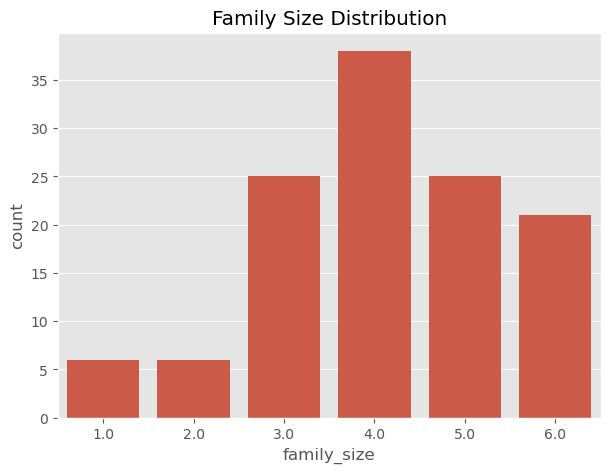

In [73]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="family_size"
)

plt.title("Family Size Distribution")
plt.show()

In [74]:
#Diet pref

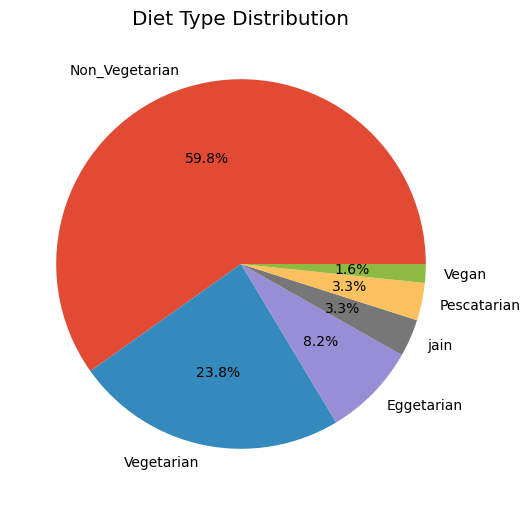

In [75]:
plt.figure(figsize=(6,6))

df["diet_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Diet Type Distribution")
plt.show()

In [76]:
#grocery freq

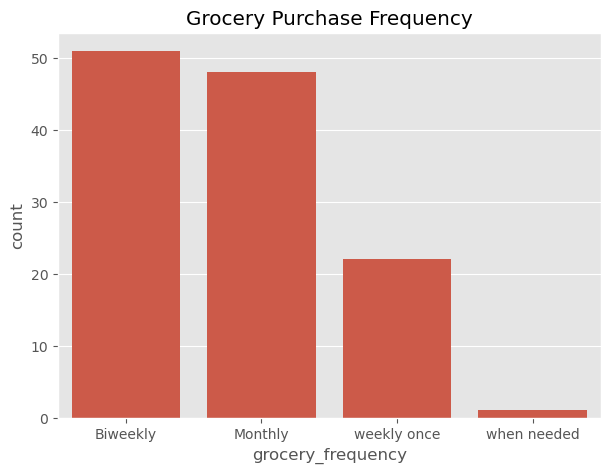

In [77]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="grocery_frequency",
    order=df["grocery_frequency"].value_counts().index
)

plt.title("Grocery Purchase Frequency")
plt.show()

In [78]:
#vegetable freq

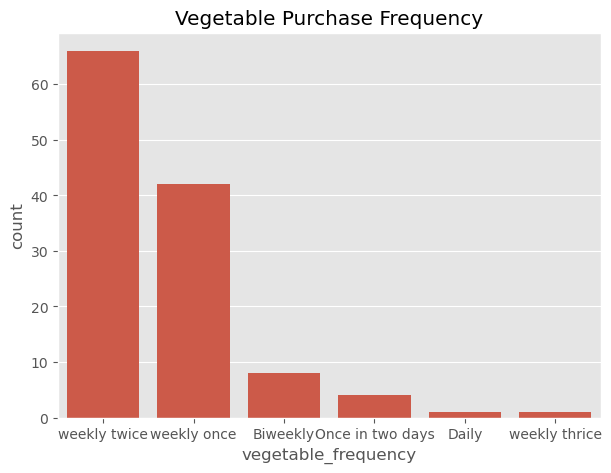

In [79]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="vegetable_frequency",
    order=df["vegetable_frequency"].value_counts().index
)

plt.title("Vegetable Purchase Frequency")
plt.show()

In [80]:
#rice consumption

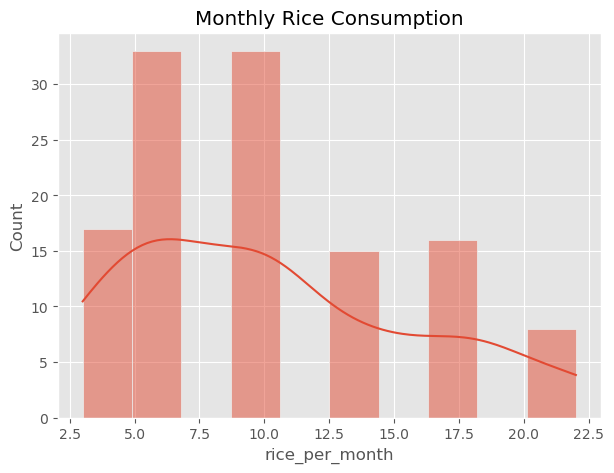

In [81]:
plt.figure(figsize=(7,5))

sns.histplot(
    df["rice_per_month"],
    bins=10,
    kde=True
)

plt.title("Monthly Rice Consumption")
plt.show()

In [82]:
#milk consumption

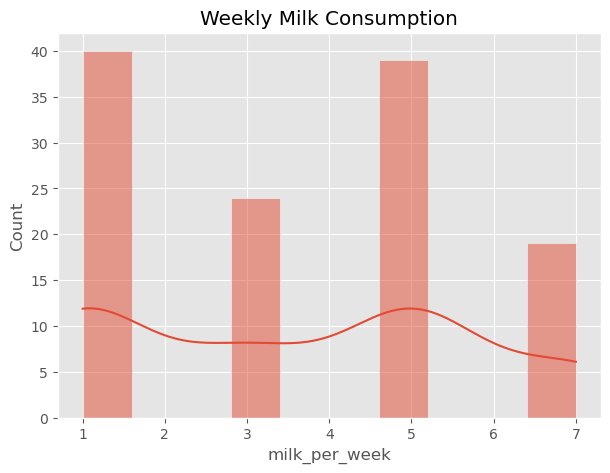

In [83]:
plt.figure(figsize=(7,5))

sns.histplot(
    df["milk_per_week"],
    bins=10,
    kde=True
)

plt.title("Weekly Milk Consumption")
plt.show()

In [84]:
#Area wise 

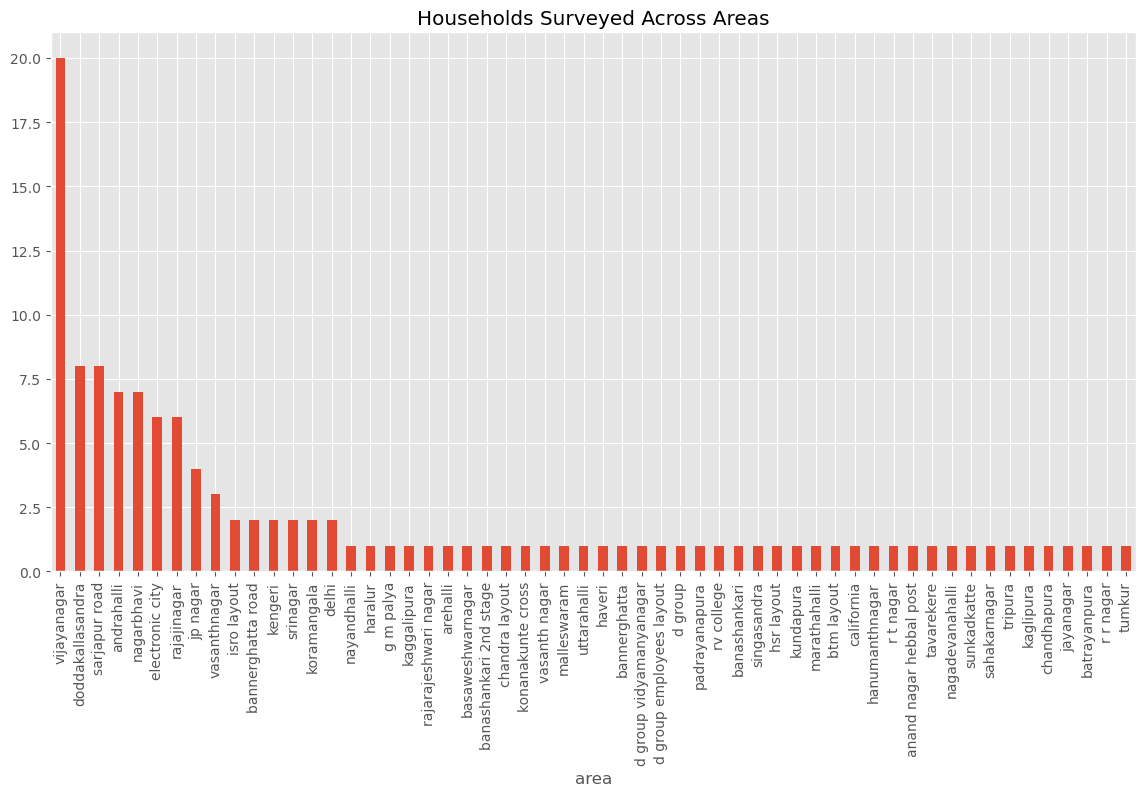

In [85]:
plt.figure(figsize=(14,7))

df["area"].value_counts().plot(kind="bar")

plt.title("Households Surveyed Across Areas")

plt.xticks(rotation=90)

plt.show()

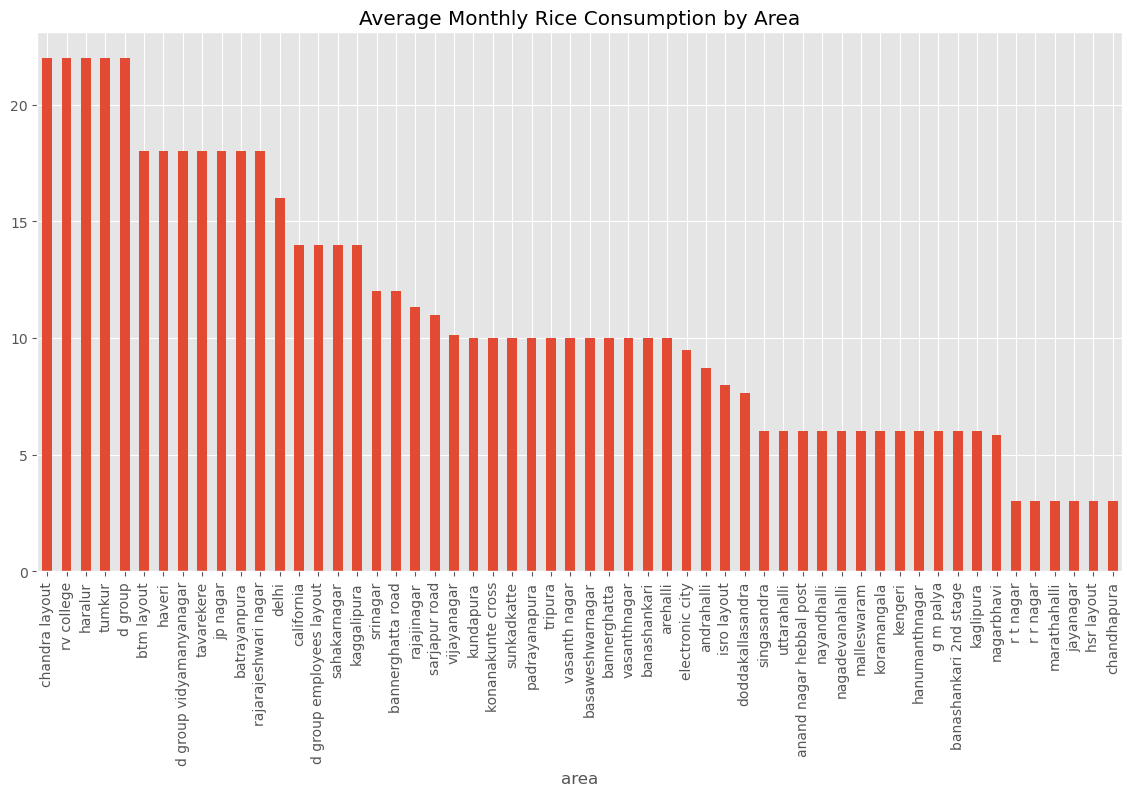

In [86]:
area_rice = (
    df.groupby("area")["rice_per_month"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,7))

area_rice.plot(kind="bar")

plt.title("Average Monthly Rice Consumption by Area")

plt.xticks(rotation=90)

plt.show()

In [87]:
#comparions: Family size: Rice consumption

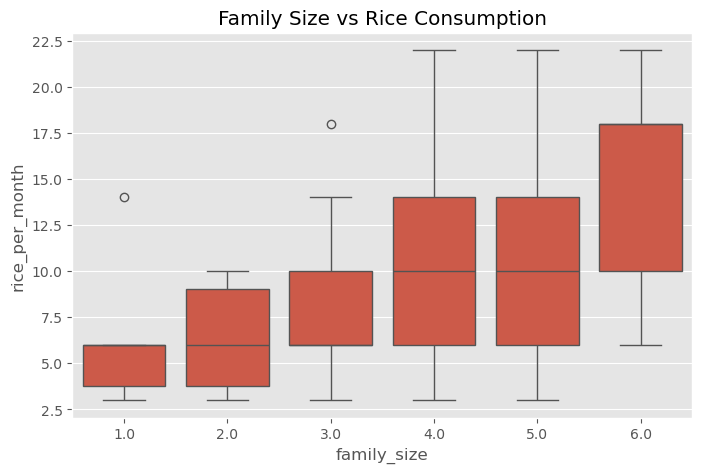

In [88]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="family_size",
    y="rice_per_month"
)

plt.title("Family Size vs Rice Consumption")

plt.show()

In [89]:
#comparions: Family size: MILK consumption

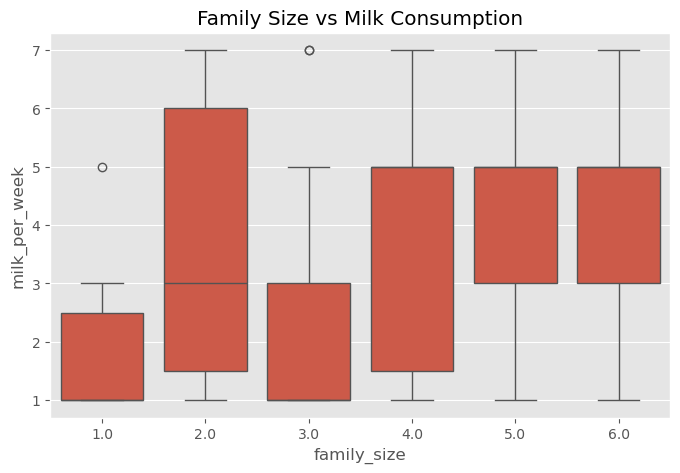

In [90]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="family_size",
    y="milk_per_week"
)

plt.title("Family Size vs Milk Consumption")

plt.show()

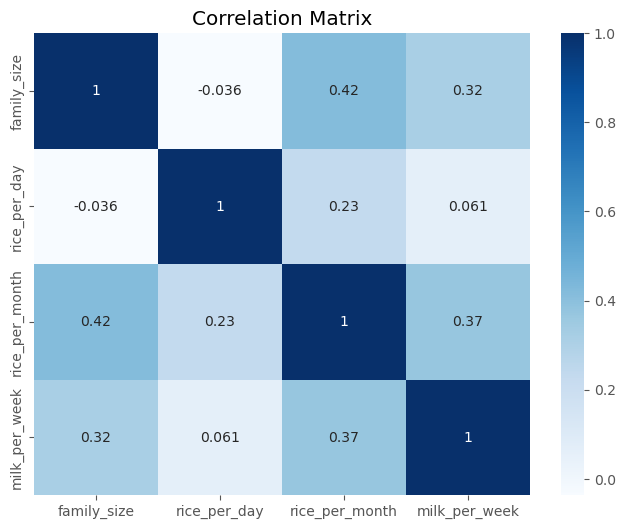

In [91]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")

plt.show()

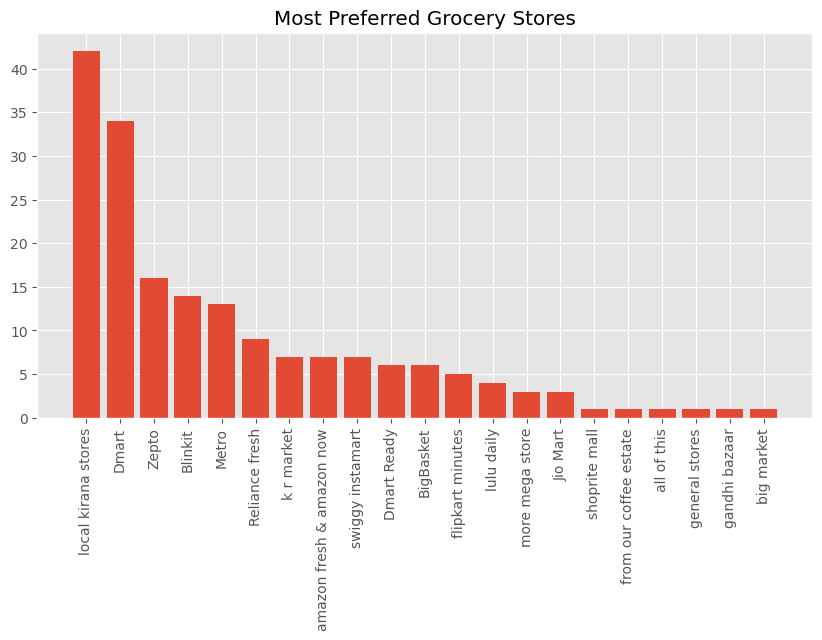

In [92]:
from collections import Counter

store_counter = Counter()

for row in df["grocery_source"].dropna():

    for store in row.split(";"):

        store_counter[store.strip()] += 1

store_df = (
    pd.DataFrame(
        store_counter.items(),
        columns=["Store","Count"]
    )
    .sort_values("Count", ascending=False)
)

plt.figure(figsize=(10,5))

plt.bar(store_df["Store"], store_df["Count"])

plt.xticks(rotation=90)

plt.title("Most Preferred Grocery Stores")

plt.show()

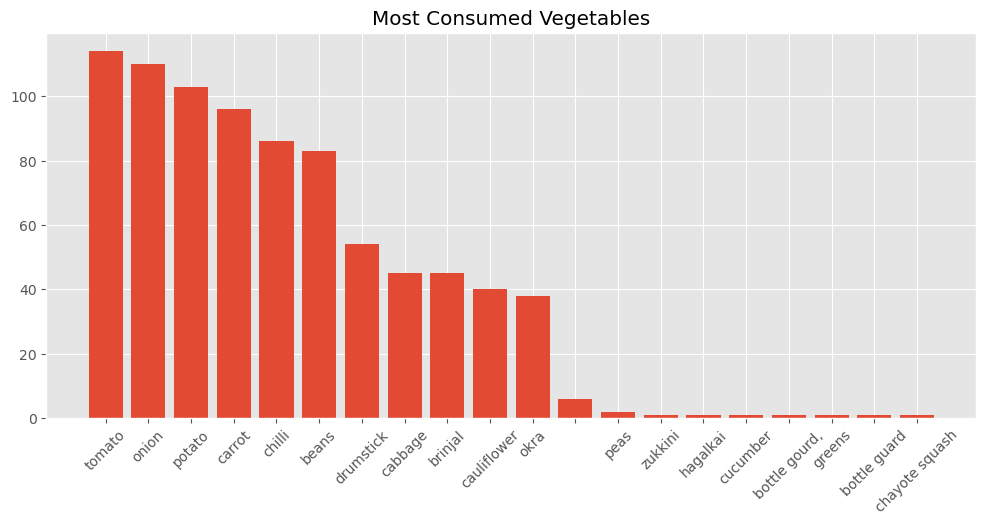

In [93]:
from collections import Counter

vegetable_counter = Counter()

for row in df["vegetables"].dropna():
    for vegetable in row.split(";"):
        vegetable_counter[vegetable.strip()] += 1

vegetable_df = (
    pd.DataFrame(
        vegetable_counter.items(),
        columns=["Vegetable","Count"]
    )
    .sort_values("Count", ascending=False)
)

plt.figure(figsize=(12,5))

plt.bar(
    vegetable_df["Vegetable"],
    vegetable_df["Count"]
)

plt.xticks(rotation=45)

plt.title("Most Consumed Vegetables")

plt.show()

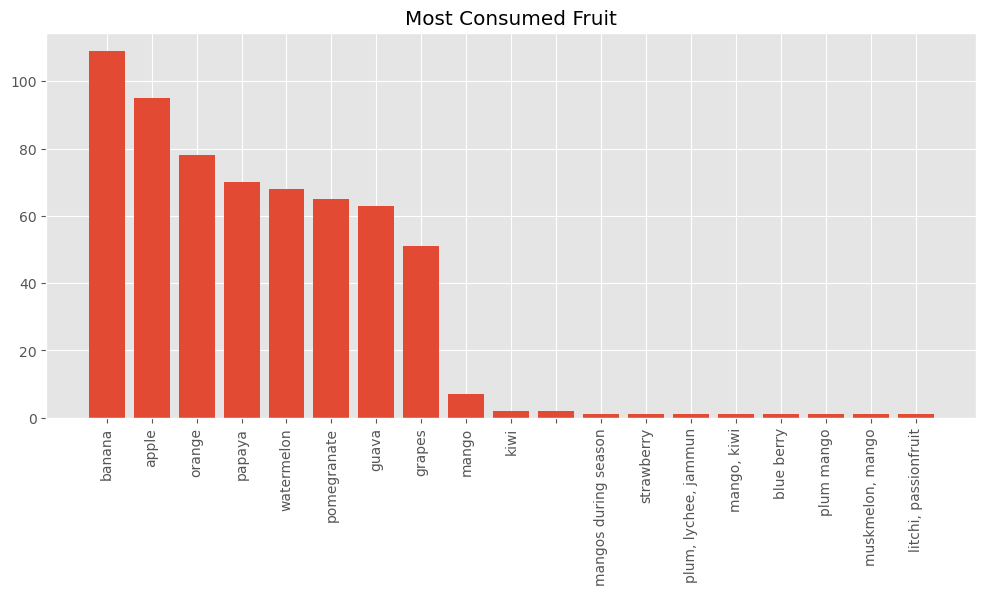

In [94]:
from collections import Counter

fruits_counter = Counter()

for row in df["fruits"].dropna():
    for fruits in row.split(";"):
        fruits_counter[fruits.strip()] += 1

fruits_df = (
    pd.DataFrame(
        fruits_counter.items(),
        columns=["Fruits","Count"]
    )
    .sort_values("Count", ascending=False)
)

plt.figure(figsize=(12,5))

plt.bar(
    fruits_df["Fruits"],
    fruits_df["Count"]
)

plt.xticks(rotation=90)

plt.title("Most Consumed Fruit")

plt.show()

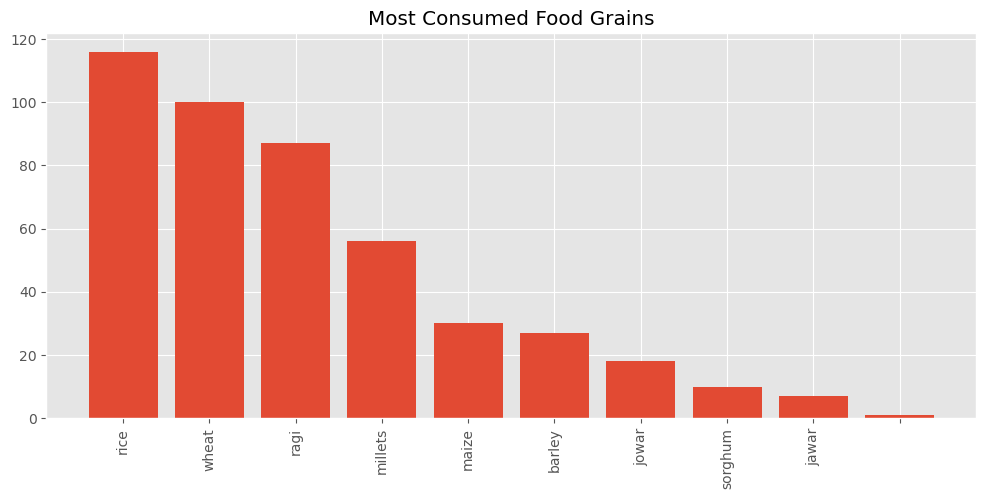

In [95]:
from collections import Counter

grain_counter = Counter()

for row in df["food_grains"].dropna():
    for grain in row.split(";"):
        grain_counter[grain.strip()] += 1

grain_df = (
    pd.DataFrame(
        grain_counter.items(),
        columns=["Food Grain","Count"]
    )
    .sort_values("Count", ascending=False)
)

plt.figure(figsize=(12,5))

plt.bar(
    grain_df["Food Grain"],
    grain_df["Count"]
)

plt.xticks(rotation=90)

plt.title("Most Consumed Food Grains")

plt.show()

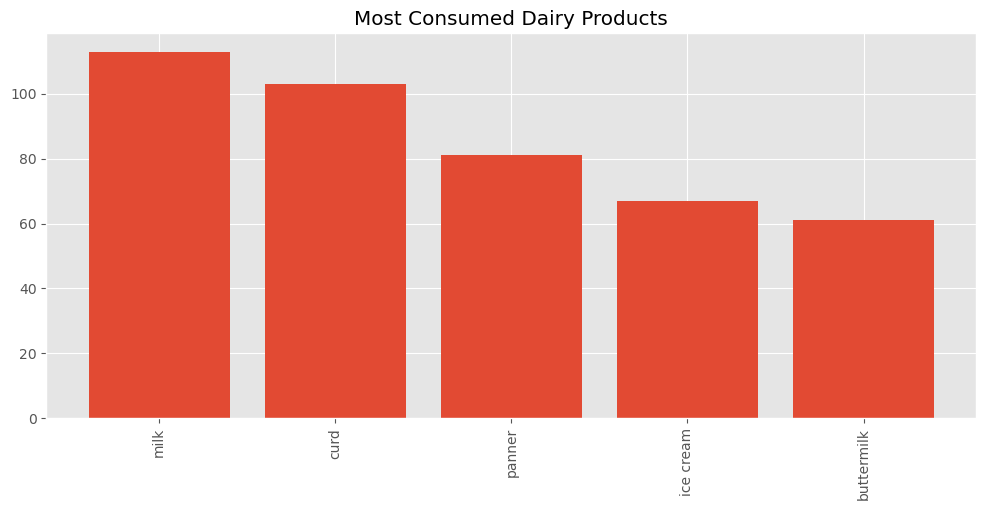

In [96]:
from collections import Counter

dairy_counter = Counter()

for row in df["dairy_products"].dropna():
    for dairy in row.split(";"):
        dairy_counter[dairy.strip()] += 1

dairy_df = (
    pd.DataFrame(
        dairy_counter.items(),
        columns=["Dairy Product","Count"]
    )
    .sort_values("Count", ascending=False)
)

plt.figure(figsize=(12,5))

plt.bar(
    dairy_df["Dairy Product"],
    dairy_df["Count"]
)

plt.xticks(rotation=90)

plt.title("Most Consumed Dairy Products")

plt.show()